*GeoPlants Dataset*

**MileStone 2**

## Load Dataset

In [22]:
## Import libraries
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os 
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import time
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report, balanced_accuracy_score)
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GridSearchCV
## CLF
## models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import AdaBoostClassifier
from sklearn.dummy import DummyClassifier
from xgboost import XGBClassifier

### Import the created function
from src.utils import merge_metadata_data

In [23]:
## Path names
base_dir = "dataset"

path_train = os.path.join(base_dir, "train_join_agg.parquet")
path_test = os.path.join(base_dir, "test_df.parquet")
ecoregions = os.path.join(base_dir, "ecoregions", "ser_l93.shp")

In [24]:
## Standard Training dataset load 
df = pd.read_parquet(path_train, engine='fastparquet')

## ETL on the dataset
## select index 
df.set_index("surveyId",inplace=True)

## Select the X train dataset | Drop non feature columns 
columns_to_drop = ['lon','lat','speciesId','predict','GRECO','codeser','index']

## X, y
Xtrain = df.drop(columns=columns_to_drop)
y = df[['predict']]


In [25]:
## Read test
df_test = pd.read_parquet(path_test, engine='fastparquet')

## Select the X train dataset | Drop non feature columns 
columns_to_drop = ['lon','lat','predict']

# ## X, y
X_test = df_test.drop(columns=columns_to_drop)
y_full_test = df_test[['predict']]

In [26]:
df.shape, df_test.shape

((13501, 53), (1386, 49))

In [27]:
df.columns.difference(df_test.columns)

Index(['GRECO', 'codeser', 'index', 'speciesId'], dtype='object')

## Pre Processing

### Data Cleaning

We need to also  **preprocessing the test df** to fill some nan values but using the train data to input the mean and median

In [28]:
## pre process the data from a single function
## cleaner notebook
from src.preprocess import big_preprocessing_step, big_preprocessing_step_test

##pre process the dataset
X = big_preprocessing_step(Xtrain)


### TEST 
print("-"*100)
print()
print(f"RUNNING TEST")

X_full_test = big_preprocessing_step_test(X_test, Xtrain, X)

Index(['footprint_HumanFootprint-NavWater1994', 'footprint_HumanFootprint-NavWater2009'], dtype='object')
 The 96% percentile of the Pop2010: 2147483647.0
 The 96% percentile of the Pop1990: 127.0
 Max value Pop2010: [2.14748365e+09]
 Max value Pop1990: [127.]
Temporal columns: ['footprint_HumanFootprint-Built1994', 'footprint_HumanFootprint-Built2009', 'footprint_HumanFootprint-croplands1992', 'footprint_HumanFootprint-croplands2005', 'footprint_HumanFootprint-Lights1994', 'footprint_HumanFootprint-Lights2009', 'footprint_HumanFootprint-NavWater1994', 'footprint_HumanFootprint-NavWater2009', 'footprint_HumanFootprint-Pasture1993', 'footprint_HumanFootprint-Pasture2009', 'footprint_HumanFootprint-Popdensity1990', 'footprint_HumanFootprint-Popdensity2010', 'footprint_HumanFootprint-HFP1993', 'footprint_HumanFootprint-HFP2009']
Newly created columns: ['Built-1994-2009', 'croplands-1992-2005', 'Lights-1994-2009', 'NavWater-1994-2009', 'Pasture-1993-2009', 'Popdensity-1990-2010', 'HFP-1993

In [29]:
X_full_test.columns == X.columns

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True])

### PreProcessor

- StandarScaler
- OneHotEncoder

In [30]:
## Name cols
cat_cols = ["landcover_LandCover"]
not_cat_cols = [col for col in X.columns if col not in cat_cols]

numeric_features = not_cat_cols
categorical_features = cat_cols 

## Numeric features
numeric_transformer = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="median")),
           ("scaler", StandardScaler())]
)


## Categorical Features
categorical_transformer = Pipeline(
                steps=[
                    ("encoder", OneHotEncoder(handle_unknown="ignore")),
                    ##("selector", SelectPercentile(chi2, percentile=50)),
                ]
)

## Column Transformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [31]:
# Convert to DataFrame
X_transformed_df = pd.DataFrame(preprocessor.fit_transform(X),
                                columns=preprocessor.get_feature_names_out(),
                                index=X.index)


In [32]:
X_transformed_df

,num__average_Bio1,num__average_Bio2,num__average_Bio3,num__average_Bio4,num__average_Bio5,num__average_Bio6,num__average_Bio7,num__average_Bio8,num__average_Bio9,num__average_Bio10,...,cat__landcover_LandCover_5.0,cat__landcover_LandCover_8.0,cat__landcover_LandCover_9.0,cat__landcover_LandCover_10.0,cat__landcover_LandCover_11.0,cat__landcover_LandCover_12.0,cat__landcover_LandCover_13.0,cat__landcover_LandCover_14.0,cat__landcover_LandCover_16.0,cat__landcover_LandCover_17.0
surveyId,,,,,,,,,,,,,,,,,,,,,
333,0.347195,0.260223,0.401941,-0.783924,0.240344,0.530852,-0.408877,0.014173,0.601191,0.108783,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
410,-0.137349,0.332205,0.401941,1.111207,0.167383,-0.400396,0.660988,-0.551047,-1.425111,0.108783,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
779,0.011741,0.116260,0.401941,-0.015829,0.057941,0.170369,-0.150633,-0.345513,-0.992833,-0.005940,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1218,-0.137349,-0.099684,0.401941,0.066002,-0.124463,0.020168,-0.150633,-0.448280,-1.046868,-0.120663,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2015,0.719922,0.836075,0.401941,1.352980,1.517168,0.140329,1.361934,1.118923,0.979434,1.179532,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3917273,-1.218257,0.188242,0.401941,-0.216687,-1.218883,-0.911081,-0.113742,1.195998,-1.722302,-1.306135,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3917646,1.539921,-0.027703,0.401941,0.246402,1.736052,1.131658,0.365853,0.784929,1.155046,1.676665,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3917824,-0.100077,-0.027703,0.401941,0.039965,-0.124463,0.080248,-0.224417,-0.396896,0.533647,-0.082422,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Cross-Validation Strategy

In [23]:
## concat dataset
Xx = pd.concat([X,df['GRECO']],axis=1).reset_index()
Xx = pd.concat([Xx,y], axis=1)

dict_train = {}
kfold = GroupKFold(n_splits=4,
                    random_state=420, shuffle=True
                   )

for i, (train_idx, test_idx) in enumerate(kfold.split(df['speciesId'],
                                                      df['predict'],
                                                      groups=df['GRECO'])):
    new_dict={}
    new_dict['train'] = train_idx
    new_dict['test']  = test_idx
    dict_train[i] = new_dict

for i in dict_train:
    print(f"    GFold: {i} - Train: {len(dict_train[i]['train'])} | Test:{len(dict_train[i]['test'])}")
for i in dict_train:   
    print(f"GFold: {i}  | Positive Rate: Train {y.iloc[dict_train[i]['train']]['predict'].mean():.3f} | Test: {y.iloc[dict_train[i]['test']]['predict'].mean():.3f} ")

    GFold: 0 - Train: 9461 | Test:4040
    GFold: 1 - Train: 8172 | Test:5329
    GFold: 2 - Train: 12162 | Test:1339
    GFold: 3 - Train: 10708 | Test:2793
GFold: 0  | Positive Rate: Train 0.432 | Test: 0.518 
GFold: 1  | Positive Rate: Train 0.537 | Test: 0.337 
GFold: 2  | Positive Rate: Train 0.475 | Test: 0.302 
GFold: 3  | Positive Rate: Train 0.401 | Test: 0.677 


In [24]:
## load the ecoregion
import re
path = 'dataset/ecoregions/ser_l93.shp'
ecogdf = gpd.read_file(path)

## Create a new column
ecogdf['GRECO'] = ecogdf['codeser'].apply(lambda x:re.findall(r'^(.+?)\d+$', x))
ecogdf['GRECO'] = ecogdf['GRECO'].apply(lambda x:x[0])

## Drop inconsistent values
ecogdf.drop(index=ecogdf.loc[ecogdf['codeser']=='-1'].index, axis=0, inplace=True)

## Convert to 4326 ## Match plant species
## Aggregate into the zones
ecogdf_4326 = ecogdf.to_crs("EPSG:4326").dissolve(by='GRECO')

GroupFold: 0
GRECO
J      3723
B      2269
C      1606
D+E     732
H       607
A       524
Name: count, dtype: int64
predict
0    5373
1    4088
Name: count, dtype: int64
GroupFold: 1
GRECO
B      2269
G      2118
F      1406
D+E     732
H       607
A       524
I+K     516
Name: count, dtype: int64
predict
1    4386
0    3786
Name: count, dtype: int64
GroupFold: 2
GRECO
J      3723
B      2269
G      2118
C      1606
F      1406
A       524
I+K     516
Name: count, dtype: int64
predict
0    6386
1    5776
Name: count, dtype: int64
GroupFold: 3
GRECO
J      3723
G      2118
C      1606
F      1406
D+E     732
H       607
I+K     516
Name: count, dtype: int64
predict
0    6418
1    4290
Name: count, dtype: int64


/tmp/ipykernel_97341/1409520789.py:46: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


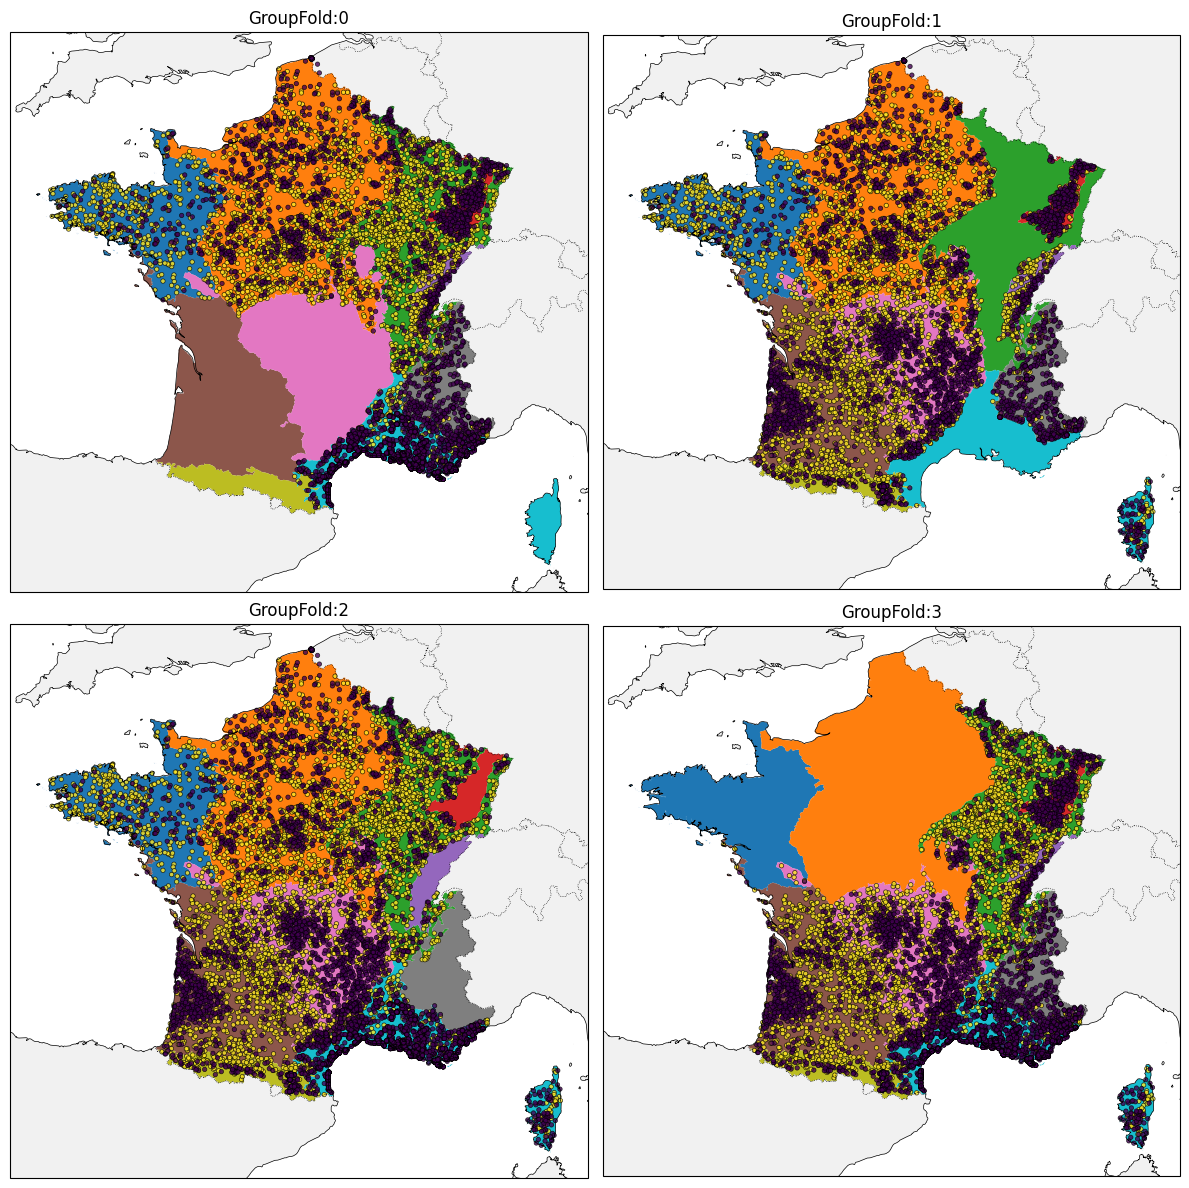

In [ ]:
## Plot to see it how the samples are being distributed
dff = df.iloc[dict_train[i]['train']]
gdf = gpd.GeoDataFrame(
                        dff,
                        geometry = gpd.points_from_xy(dff["lon"],
                                                     dff["lat"]),
                        crs="EPSG:4326"
)

fig, ax = plt.subplots(nrows=2,ncols=2, figsize=(12,12),
                       subplot_kw={'projection': ccrs.PlateCarree()}
                       )
ax = ax.flatten()
for i in dict_train.keys():
    ## select the df 
    dff = df.iloc[dict_train[i]['train']]
    print(f"GroupFold: {i}")
    print(dff['GRECO'].value_counts())
    print(dff['predict'].value_counts())
    gdf = gpd.GeoDataFrame(dff,
                            geometry = gpd.points_from_xy(dff["lon"],
                                                        dff["lat"]),
                            crs="EPSG:4326"
    )
    ax[i].add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=':')
    ax[i].add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)
    ax[i].add_feature(cfeature.COASTLINE, linewidth=0.5) 
    
    ## plot the ecoregion
    ecogdf_4326.plot(column=ecogdf_4326.index,
                    ax=ax[i],
                    legend=False)

    gdf.plot(
        column='predict',
        cmap='viridis',
        legend=False,
        ax=ax[i],
        markersize=10,
        edgecolor='black',
        linewidth=0.5,
        alpha=0.8
    )
    ax[i].set_title(f"GroupFold:{i}")

plt.tight_layout()
#plt.close()

## Evaluating a suite of ML Models

In [10]:
from sklearn.model_selection import cross_validate
from src.inference import evaluate_with_group_kfold, describe_kfold_results
from src.plot import plot_cm



In [11]:
## Stardard X,y and Group
y_vec = y['predict'] if isinstance(y, pd.DataFrame) else y
groups = df.loc[X.index, 'GRECO']  # ensure alignment


Evaluating: KNN
- - - - - - - - - - 



------------------------------
Folder: 0
              precision    recall  f1-score   support

           0       0.69      0.61      0.65      1948
           1       0.67      0.75      0.71      2092

    accuracy                           0.68      4040
   macro avg       0.68      0.68      0.68      4040
weighted avg       0.68      0.68      0.68      4040

------------------------------
Folder: 1
              precision    recall  f1-score   support

           0       0.87      0.57      0.69      3535
           1       0.50      0.84      0.62      1794

    accuracy                           0.66      5329
   macro avg       0.69      0.70      0.66      5329
weighted avg       0.75      0.66      0.67      5329

------------------------------
Folder: 2
              precision    recall  f1-score   support

           0       0.80      0.81      0.81       935
           1       0.55      0.54      0.55       404

    accuracy                           0.73      1339
   ma

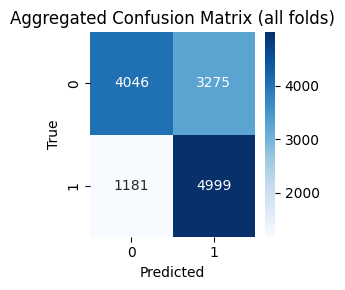

KNN | Time taken: 5.60

Evaluating: AdaBoost
- - - - - - - - - - 

------------------------------
Folder: 0
              precision    recall  f1-score   support

           0       0.72      0.52      0.60      1948
           1       0.64      0.81      0.72      2092

    accuracy                           0.67      4040
   macro avg       0.68      0.66      0.66      4040
weighted avg       0.68      0.67      0.66      4040

------------------------------
Folder: 1
              precision    recall  f1-score   support

           0       0.82      0.81      0.82      3535
           1       0.64      0.66      0.65      1794

    accuracy                           0.76      5329
   macro avg       0.73      0.74      0.73      5329
weighted avg       0.76      0.76      0.76      5329

------------------------------
Folder: 2
              precision    recall  f1-score   support

           0       0.80      0.77      0.79       935
           1       0.51      0.55      0.53    

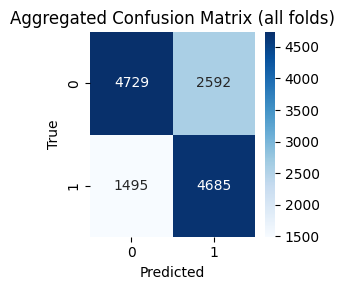

AdaBoost | Time taken: 68.63

Evaluating: LogisticRegression
- - - - - - - - - - 

------------------------------
Folder: 0
              precision    recall  f1-score   support

           0       0.71      0.58      0.64      1948
           1       0.67      0.78      0.72      2092

    accuracy                           0.68      4040
   macro avg       0.69      0.68      0.68      4040
weighted avg       0.69      0.68      0.68      4040

------------------------------
Folder: 1
              precision    recall  f1-score   support

           0       0.71      0.17      0.28      3535
           1       0.35      0.86      0.49      1794

    accuracy                           0.40      5329
   macro avg       0.53      0.52      0.38      5329
weighted avg       0.59      0.40      0.35      5329

------------------------------
Folder: 2
              precision    recall  f1-score   support

           0       0.85      0.76      0.80       935
           1       0.56      0.

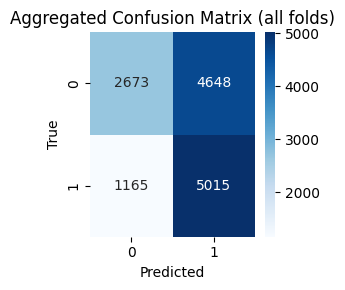

LogisticRegression | Time taken: 24.94

Evaluating: GaussianNB
- - - - - - - - - - 

------------------------------
Folder: 0
              precision    recall  f1-score   support

           0       0.82      0.28      0.42      1948
           1       0.58      0.94      0.72      2092

    accuracy                           0.62      4040
   macro avg       0.70      0.61      0.57      4040
weighted avg       0.70      0.62      0.58      4040

------------------------------
Folder: 1
              precision    recall  f1-score   support

           0       0.86      0.35      0.50      3535
           1       0.41      0.89      0.56      1794

    accuracy                           0.53      5329
   macro avg       0.64      0.62      0.53      5329
weighted avg       0.71      0.53      0.52      5329

------------------------------
Folder: 2
              precision    recall  f1-score   support

           0       0.82      0.61      0.70       935
           1       0.43      

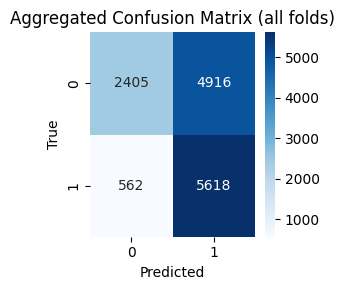

GaussianNB | Time taken: 0.99

Evaluating: SVC
- - - - - - - - - - 

------------------------------
Folder: 0
              precision    recall  f1-score   support

           0       0.69      0.59      0.64      1948
           1       0.66      0.75      0.71      2092

    accuracy                           0.67      4040
   macro avg       0.68      0.67      0.67      4040
weighted avg       0.68      0.67      0.67      4040

------------------------------
Folder: 1
              precision    recall  f1-score   support

           0       0.84      0.68      0.75      3535
           1       0.54      0.74      0.63      1794

    accuracy                           0.70      5329
   macro avg       0.69      0.71      0.69      5329
weighted avg       0.74      0.70      0.71      5329

------------------------------
Folder: 2
              precision    recall  f1-score   support

           0       0.89      0.70      0.78       935
           1       0.54      0.79      0.64  

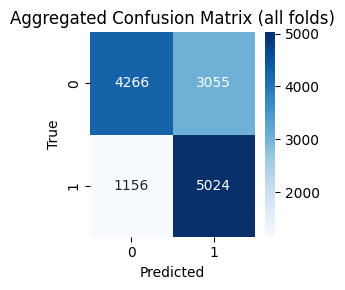

SVC | Time taken: 258.54

Evaluating: HistGradBoost
- - - - - - - - - - 

------------------------------
Folder: 0
              precision    recall  f1-score   support

           0       0.67      0.56      0.61      1948
           1       0.65      0.75      0.69      2092

    accuracy                           0.66      4040
   macro avg       0.66      0.66      0.65      4040
weighted avg       0.66      0.66      0.66      4040

------------------------------
Folder: 1
              precision    recall  f1-score   support

           0       0.75      0.61      0.67      3535
           1       0.44      0.60      0.50      1794

    accuracy                           0.60      5329
   macro avg       0.59      0.60      0.59      5329
weighted avg       0.64      0.60      0.61      5329

------------------------------
Folder: 2
              precision    recall  f1-score   support

           0       0.83      0.82      0.82       935
           1       0.59      0.62      0

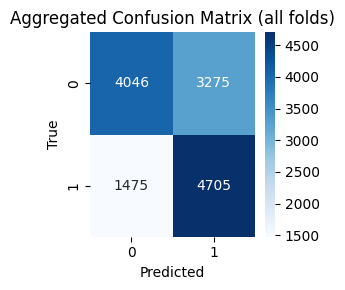

HistGradBoost | Time taken: 21.05

Evaluating: RF
- - - - - - - - - - 

------------------------------
Folder: 0
              precision    recall  f1-score   support

           0       0.72      0.59      0.65      1948
           1       0.67      0.78      0.72      2092

    accuracy                           0.69      4040
   macro avg       0.70      0.69      0.69      4040
weighted avg       0.69      0.69      0.69      4040

------------------------------
Folder: 1
              precision    recall  f1-score   support

           0       0.78      0.81      0.80      3535
           1       0.60      0.55      0.57      1794

    accuracy                           0.72      5329
   macro avg       0.69      0.68      0.68      5329
weighted avg       0.72      0.72      0.72      5329

------------------------------
Folder: 2
              precision    recall  f1-score   support

           0       0.84      0.82      0.83       935
           1       0.61      0.65      0.6

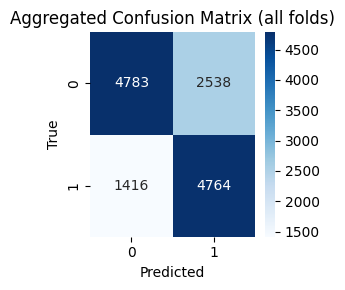

RF | Time taken: 89.34

Evaluating: Dummy_MostFrequent
- - - - - - - - - - 

------------------------------
Folder: 0
              precision    recall  f1-score   support

           0       0.48      1.00      0.65      1948
           1       0.00      0.00      0.00      2092

    accuracy                           0.48      4040
   macro avg       0.24      0.50      0.33      4040
weighted avg       0.23      0.48      0.31      4040

------------------------------
Folder: 1
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      3535
           1       0.34      1.00      0.50      1794

    accuracy                           0.34      5329
   macro avg       0.17      0.50      0.25      5329
weighted avg       0.11      0.34      0.17      5329

------------------------------
Folder: 2
              precision    recall  f1-score   support

           0       0.70      1.00      0.82       935
           1       0.00      0.00    

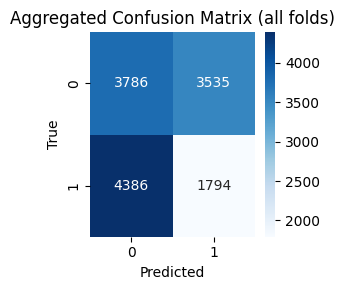

Dummy_MostFrequent | Time taken: 0.92

Evaluating: Dummy_Stratified
- - - - - - - - - - 

------------------------------
Folder: 0
              precision    recall  f1-score   support

           0       0.49      0.56      0.52      1948
           1       0.52      0.45      0.48      2092

    accuracy                           0.50      4040
   macro avg       0.50      0.50      0.50      4040
weighted avg       0.50      0.50      0.50      4040

------------------------------
Folder: 1
              precision    recall  f1-score   support

           0       0.66      0.48      0.56      3535
           1       0.34      0.52      0.41      1794

    accuracy                           0.49      5329
   macro avg       0.50      0.50      0.48      5329
weighted avg       0.55      0.49      0.51      5329

------------------------------
Folder: 2
              precision    recall  f1-score   support

           0       0.71      0.55      0.62       935
           1       0.31 

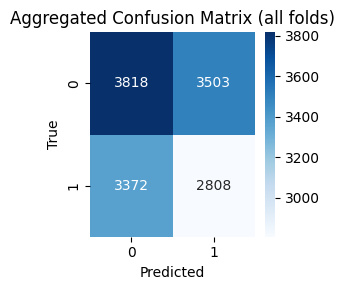

Dummy_Stratified | Time taken: 0.89


In [ ]:
## suit of models
models = [
    ("KNN", KNeighborsClassifier(n_neighbors=50, n_jobs=-1)),
    ("AdaBoost", AdaBoostClassifier(n_estimators=350, random_state=420)),
    ("LogisticRegression", LogisticRegression(max_iter=1000)),
    ("GaussianNB", GaussianNB()),
    ("SVC", SVC(probability=True, kernel='rbf', C=1.0, random_state=420)),
    ("HistGradBoost", HistGradientBoostingClassifier(max_iter=500, random_state=420)),
    ("RF", RandomForestClassifier(n_estimators=700, random_state=420, n_jobs=-1)),
    ("Dummy_MostFrequent",DummyClassifier(strategy="most_frequent")),
    ("Dummy_Stratified",DummyClassifier(strategy="stratified")),
]

# dict to store results
big_dict_all_classifiers = {}

# Loop through models
for model_name, model in models:
    print(f"\n{'='*100}")
    print(f"Evaluating: {model_name}")
    print(f"{'- '*10}\n")
    
    start_time = time.time()
    
    # Create pipeline
    clf = Pipeline([
        ("preproc", preprocessor),
        (model_name, model)
    ])
    
    # Evaluate
    scores = evaluate_with_group_kfold(clf, X, y_vec, groups, verbose=True)
    
    # Create DataFrame from scores
    df_scores = pd.DataFrame(scores)
    
    # Display results
    print(f"\n--- Results for {model_name} ---")
    describe_kfold_results(df_scores)
    
    # Plot confusion matrix
    total_cm = np.sum(df_scores["confusion_matrix"].to_list(), axis=0)
    plot_cm(total_cm, figsize=(3,3))
    
    # Store results
    big_dict_all_classifiers[model_name] = df_scores
    
    time_taken =  time.time() - start_time
    print(f"{model_name} | Time taken: {time_taken:.2f}")

In [ ]:
from src.utils import export_cv_clfs_metrics
        
## exporting my table in folder
df_result = export_cv_clfs_metrics(big_dict_all_classifiers,
                       export=True,
                       file_name='model_results_d')


,recall,precision,f1,accuracy,balanced_accuracy,roc_auc,confusion_matrix
0,0.502970,0.505934,0.501191,0.502970,0.505200,0.493790,"[[1106, 842], [1166, 926]]"
1,0.485082,0.549225,0.498477,0.485082,0.495481,0.485090,"[[1639, 1896], [848, 946]]"
2,0.531740,0.596190,0.550610,0.531740,0.521322,0.476386,"[[512, 423], [204, 200]]"
3,0.477981,0.571634,0.490510,0.477981,0.509610,0.495632,"[[541, 362], [1096, 794]]"


## ploting

In [ ]:
## Construct a multi-level df 
## the first column level is the name of the classifier and the second level are the metrics 
big_dict = big_dict_all_classifiers.copy()
dfs = []
for model_name, df in big_dict.items():
    # first level = model name, second level = metric name
    df.columns = pd.MultiIndex.from_product([[model_name], df.columns])
    dfs.append(df)

# concat
multi_df = pd.concat(dfs, axis=1)

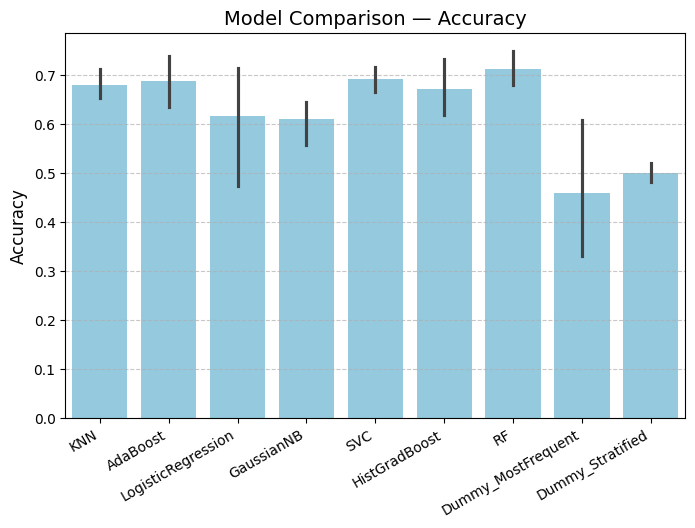

In [21]:
plt.figure(figsize=(8, 5))
sns.barplot(data=multi_df.xs('accuracy', level=1, axis=1),
            color='skyblue')
plt.title('Model Comparison — Accuracy', fontsize=14)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


### Plotting in R 
cause R is cooler :)

In [19]:
%load_ext rpy2.ipython  

In [ ]:
## vars 
file_output = "result_imgs/my_plot2.png"
width = 9
height = 7
dpi=100

"#E6E6E8"

In [37]:
%%R -i file_output,width,height,dpi

library(ggplot2)
suppressMessages(library(dplyr))
suppressMessages(library(tidyverse))

## figsize
## options(repr.plot.width = 10, repr.plot.height = 8)

# Load
dataf <- readr::read_csv("tmp_csv/model_results_d.csv", col_names=TRUE, show_col_types = FALSE)
metrics_col <- c("recall","precision","f1","accuracy","balanced_accuracy","roc_auc")

## exclude confusion matrix
datafilter <- dataf |> 
                    filter(metric != "confusion_matrix") |>
                    mutate(value = as.numeric(value))
# plot
p <- ggplot(datafilter |> filter(metric != "kfold"),
            aes(x = model, y = value, fill = metric)
        ) +
  stat_summary(fun = mean, geom = "bar", position = "dodge") +
  stat_summary(fun.data = mean_se, geom = "errorbar", 
               #position = position_dodge(width = 0.9),
                width = 0.05, color='#444343ff') +
  labs(title = "Comparison of Models",
       x = NULL, y = "Score") +
    scale_fill_brewer(palette = "Blues")+
    theme_minimal() +
    theme(axis.text.x = element_text(angle = 45, hjust = 1),
            plot.background = element_rect(fill = "#E6E6E8", color = NA),
            plot.title = element_text(hjust = 0.5, face = "bold"),
            panel.grid.minor.y = element_blank()
        ) 
    
##print(p) 

ggsave(file_output,    
       width = width,           
       height = height,          
       dpi = dpi)  

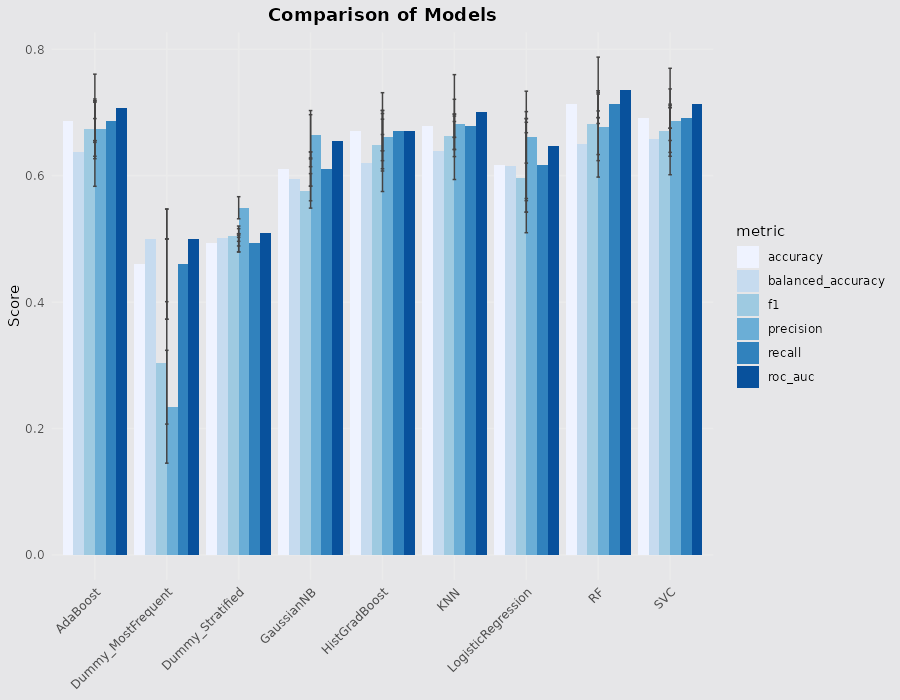

In [38]:
from IPython.display import Image

Image(file_output, width=width*dpi, height=height*dpi)

## Feature Selection for better accuracy

Permutation Importance

Uses permutation to understand how the features affect the error

### Permutation Importance on the GroupKFold

Fold 0: acc shape = (39,), rec shape = (39,), raw features = 39
Fold 1: acc shape = (39,), rec shape = (39,), raw features = 39


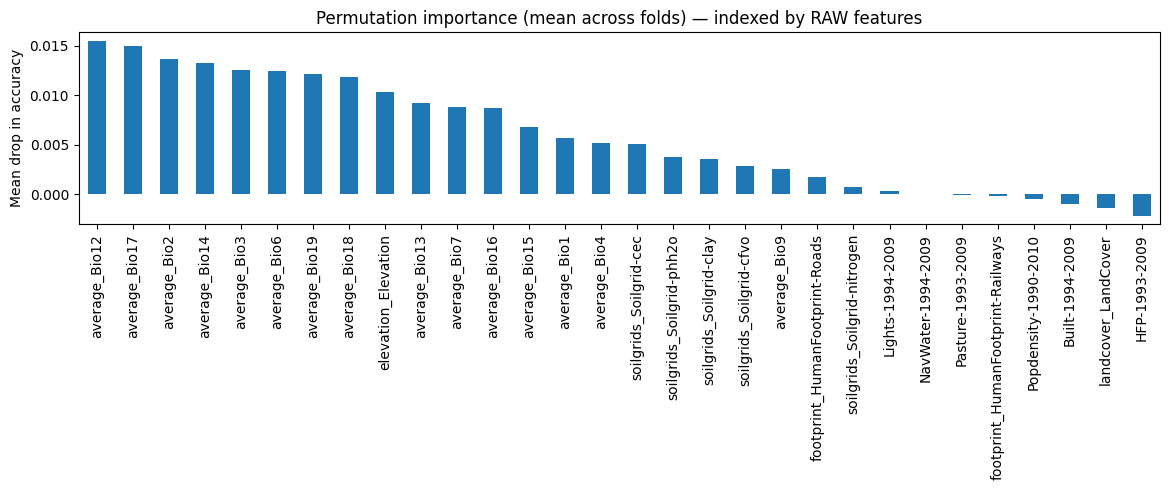

average_Bio12                        0.015455
average_Bio17                        0.014980
average_Bio2                         0.013615
average_Bio14                        0.013201
average_Bio3                         0.012541
average_Bio6                         0.012431
average_Bio19                        0.012164
average_Bio18                        0.011844
elevation_Elevation                  0.010358
average_Bio13                        0.009208
average_Bio7                         0.008820
average_Bio16                        0.008755
average_Bio15                        0.006827
average_Bio1                         0.005671
average_Bio4                         0.005168
soilgrids_Soilgrid-cec               0.005079
soilgrids_Soilgrid-phh2o             0.003734
soilgrids_Soilgrid-clay              0.003573
soilgrids_Soilgrid-cfvo              0.002809
average_Bio9                         0.002546
footprint_HumanFootprint-Roads       0.001728
soilgrids_Soilgrid-nitrogen       

In [12]:
from sklearn.inspection import permutation_importance

n_splits = 2
gkf = GroupKFold(n_splits=n_splits,
                 shuffle=True,
                 random_state=420)

groups = df.loc[X.index, 'GRECO']
y_vec = y['predict'] if isinstance(y, pd.DataFrame) else y

raw_feat_names = X.columns.to_list()   # RAW feature names

# perm_vals = []
perm_vals_acc = []
perm_vals_rec = []

for fold_i, (train_idx, test_idx) in enumerate(gkf.split(X, y_vec, groups=groups)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y_vec.iloc[train_idx], y_vec.iloc[test_idx]

    pipe = Pipeline([
        ("preproc", preprocessor),   # the ColumnTransformer
        ("clf", RandomForestClassifier(n_estimators=700,
                                       random_state=0,
                                       n_jobs=-1)
        )
    ])
    
    pipe.fit(X_train, y_train) 

    # compute permutation importance ON THE RAW X_test
    r = permutation_importance(pipe, X_test, y_test, n_repeats=5, random_state=0, n_jobs=-1, scoring=['accuracy','recall'])
    acc_imp = r['accuracy']
    rec_imp = r['recall']
    print(f"Fold {fold_i}: "
      f"acc shape = {acc_imp.importances_mean.shape}, "
      f"rec shape = {rec_imp.importances_mean.shape}, "
      f"raw features = {len(raw_feat_names)}")
    perm_vals_acc.append(acc_imp.importances_mean)
    perm_vals_rec.append(rec_imp.importances_mean)

# stack and average across folds
perm_arr = np.vstack(perm_vals_acc)                # shape (n_splits, n_raw_features)
perm_mean = perm_arr.mean(axis=0)              # length == n_raw_features

# Create a Series indexed by RAW feature names
perm_series = pd.Series(perm_mean, index=raw_feat_names).sort_values(ascending=False)

# Plot top 25 raw features
plt.figure(figsize=(12,5))
perm_series.head(30).plot(kind='bar')
plt.title("Permutation importance (mean across folds) — indexed by RAW features")
plt.ylabel("Mean drop in accuracy")
plt.tight_layout()
plt.show()

# Print the top features
print(perm_series.head(40))

In [ ]:
### Saving it
pd.Series(perm_series).to_csv("results/2fold_selected_features_index.csv", index=True)

perm_series

average_Bio12                        0.015455
average_Bio17                        0.014980
average_Bio2                         0.013615
average_Bio14                        0.013201
average_Bio3                         0.012541
average_Bio6                         0.012431
average_Bio19                        0.012164
average_Bio18                        0.011844
elevation_Elevation                  0.010358
average_Bio13                        0.009208
average_Bio7                         0.008820
average_Bio16                        0.008755
average_Bio15                        0.006827
average_Bio1                         0.005671
average_Bio4                         0.005168
soilgrids_Soilgrid-cec               0.005079
soilgrids_Soilgrid-phh2o             0.003734
soilgrids_Soilgrid-clay              0.003573
soilgrids_Soilgrid-cfvo              0.002809
average_Bio9                         0.002546
footprint_HumanFootprint-Roads       0.001728
soilgrids_Soilgrid-nitrogen       

### Permutation Importance - 4 kfolds

In [ ]:
n_splits = 4
gkf = GroupKFold(n_splits=n_splits,
                 shuffle=True,
                 random_state=420)
groups = df.loc[X.index, 'GRECO']
y_vec = y['predict'] if isinstance(y, pd.DataFrame) else y

raw_feat_names = X.columns.to_list()   # RAW feature names
# perm_vals = []
perm_vals_acc = []
perm_vals_rec = []

for fold_i, (train_idx, test_idx) in enumerate(gkf.split(X, y_vec, groups=groups)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y_vec.iloc[train_idx], y_vec.iloc[test_idx]

    pipe = Pipeline([
        ("preproc", preprocessor),   # the ColumnTransformer
        ("clf", RandomForestClassifier(n_estimators=700,
                                       random_state=0,
                                       n_jobs=-1)
        )
    ])
    
    
    pipe.fit(X_train, y_train) 

    # compute permutation importance ON THE RAW X_test
    r = permutation_importance(pipe, X_test, y_test, n_repeats=5, random_state=0, n_jobs=-1, scoring=['accuracy','recall'])
    acc_imp = r['accuracy']
    rec_imp = r['recall']
    print(f"Fold {fold_i}: "
      f"acc shape = {acc_imp.importances_mean.shape}, "
      f"rec shape = {rec_imp.importances_mean.shape}, "
      f"raw features = {len(raw_feat_names)}")
    perm_vals_acc.append(acc_imp.importances_mean)
    perm_vals_rec.append(rec_imp.importances_mean)
    # print(f"Fold {fold_i}: perm importances shape = {r.importances_mean.shape}, raw features = {len(raw_feat_names)}")
    
    ## now the r is a dictionary with accuracy, recall 
    # perm_vals.append(r['accuracy'].importances_mean)

# stack and average across folds
perm_arr = np.vstack(perm_vals_acc)                # shape (n_splits, n_raw_features)
perm_mean = perm_arr.mean(axis=0)              # length == n_raw_features

# Create a Series indexed by RAW feature names
perm_series = pd.Series(perm_mean, index=raw_feat_names).sort_values(ascending=False)

# Plot top 25 raw features
plt.figure(figsize=(12,5))
perm_series.head(30).plot(kind='bar')
plt.title("Permutation importance (mean across folds) — indexed by RAW features")
plt.ylabel("Mean drop in accuracy")
plt.tight_layout()
plt.show()

# Print the top features
print(perm_series.head(40))

In [ ]:
dfi.loc[dfi['acc_mean']<0][['features','acc_mean']]

0                          average_Bio1
1                          average_Bio2
2                          average_Bio3
3                          average_Bio4
4                          average_Bio5
5                          average_Bio6
6                          average_Bio7
7                          average_Bio8
8                          average_Bio9
9                         average_Bio10
10                        average_Bio11
11                        average_Bio12
12                        average_Bio13
13                        average_Bio14
14                        average_Bio15
15                        average_Bio16
16                        average_Bio17
17                        average_Bio18
18                        average_Bio19
19                  elevation_Elevation
20                  landcover_LandCover
21              soilgrids_Soilgrid-bdod
22               soilgrids_Soilgrid-cec
23              soilgrids_Soilgrid-cfvo
24              soilgrids_Soilgrid-clay


<Figure size 1200x500 with 0 Axes>

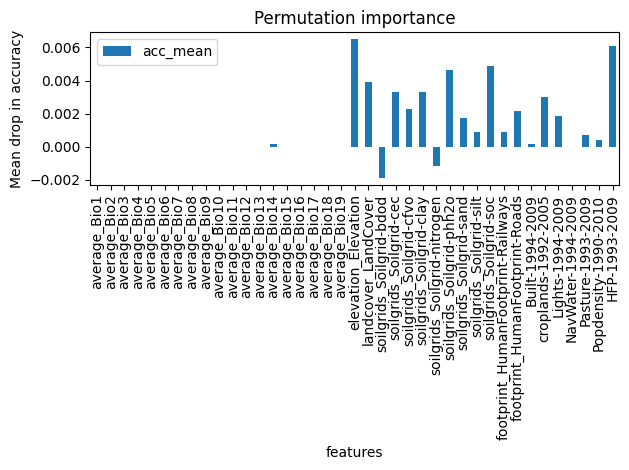

In [52]:
plt.figure(figsize=(12,5))
dfi[['acc_mean','features']].set_index('features').plot(kind='bar')
plt.title("Permutation importance")
plt.ylabel("Mean drop in accuracy")
plt.tight_layout()
plt.show()

In [53]:
## save the features
### Saving it
dfi[['features','acc_mean']].to_csv("results/alltest_selected_features_index.csv", index=True)



## PCA

PCA and GridSearch with GroupKFold 

In [ ]:



## create pipeline 
pipeline = Pipeline(
    [
       ( "preprocess",preprocessor),
       ("reduce_dim","passthrough"),
        ("clf",RandomForestClassifier(n_estimators=700,
                                     random_state=420,
                                     n_jobs=-1)
         )
    ]
)

N_FEATURES_OPTIONS = [3, 5, 8]

param_grid = [
    {
        "reduce_dim": [PCA(iterated_power=7)],
        "reduce_dim__n_components": N_FEATURES_OPTIONS
    }
]
 
grid = GridSearchCV(
    pipeline,
    n_jobs=1,
    param_grid = param_grid
)       

#fit
grid.fit(X,y)


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: 

In [73]:
grid.best_params_

{'reduce_dim': PCA(iterated_power=7), 'reduce_dim__n_components': 8}

In [74]:
grid.best_score_

np.float64(0.78809009009009)

In [75]:
## Apply the PCA for the best parameter

pca = PCA(n_components=8)

## fit on the whole dataset
pca.fit(X)

## 
print(f"Explained Variance Ratio")
print(pca.explained_variance_ratio_)

## Transform
X_pca = pca.fit_transform(X)

Explained Variance Ratio
[0.8299279  0.0893826  0.0506781  0.01205513 0.00646008 0.00532781
 0.00310595 0.00214926]


## Grid Search

### Random Forest

#### Full Dataset

In [24]:
from sklearn.model_selection import GridSearchCV

In [ ]:
cat_cols = [c for c in X.columns if c.startswith('landcover') or X[c].dtype == 'object']
num_cols = [c for c in X.columns if c not in cat_cols]

# Preprocessor
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

# RF pipeline
pipe_rf = Pipeline([
    ("preproc", preprocessor),
    ("clf", RandomForestClassifier(random_state=420))
])

# Hyperparameter grid
param_grid_rf = {
    "clf__n_estimators": [50,100,500,700,1000], 
    "clf__max_depth": [3,5,7,10,15],
    "clf__min_samples_split": [5],
    # "clf__min_samples_leaf": [1, 2, 4]
}

##groupKfold
groups = df.loc[X.index, 'GRECO']
gkf = GroupKFold(n_splits=4, random_state=420, shuffle=True)

# GridSearchCV
grid_rf = GridSearchCV(
    estimator=pipe_rf,
    param_grid=param_grid_rf,
    scoring='accuracy',
    cv=gkf.split(X,y.values,groups=groups),
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

# Fit
grid_rf.fit(X, y.values)

# Best parameters & score
print("Best RF params:", grid_rf.best_params_)
print("Best RF accuracy:", grid_rf.best_score_)

## pass it to a df
dfgs = pd.DataFrame(grid_rf.cv_results_)
dfgs.to_csv('results/grid_search_RF_full_df2.csv')

Fitting 4 folds for each of 25 candidates, totalling 100 fits


/home/manecomaneca/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/manecomaneca/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/manecomaneca/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/e

[CV] END clf__max_depth=3, clf__min_samples_split=5, clf__n_estimators=50; total time=   1.2s
[CV] END clf__max_depth=3, clf__min_samples_split=5, clf__n_estimators=50; total time=   1.2s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=3, clf__min_samples_split=5, clf__n_estimators=50; total time=   1.5s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=3, clf__min_samples_split=5, clf__n_estimators=50; total time=   2.1s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=3, clf__min_samples_split=5, clf__n_estimators=100; total time=   4.2s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=3, clf__min_samples_split=5, clf__n_estimators=100; total time=   4.6s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=3, clf__min_samples_split=5, clf__n_estimators=100; total time=   4.6s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=3, clf__min_samples_split=5, clf__n_estimators=100; total time=   3.5s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=3, clf__min_samples_split=5, clf__n_estimators=500; total time=  13.9s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=3, clf__min_samples_split=5, clf__n_estimators=500; total time=  12.2s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=3, clf__min_samples_split=5, clf__n_estimators=500; total time=  18.0s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=3, clf__min_samples_split=5, clf__n_estimators=500; total time=  14.8s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=3, clf__min_samples_split=5, clf__n_estimators=700; total time=  17.1s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=3, clf__min_samples_split=5, clf__n_estimators=700; total time=  16.2s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=3, clf__min_samples_split=5, clf__n_estimators=700; total time=  18.1s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=3, clf__min_samples_split=5, clf__n_estimators=700; total time=  16.8s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=3, clf__min_samples_split=5, clf__n_estimators=1000; total time=  20.7s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=3, clf__min_samples_split=5, clf__n_estimators=1000; total time=  22.4s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=5, clf__min_samples_split=5, clf__n_estimators=50; total time=   1.6s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=5, clf__min_samples_split=5, clf__n_estimators=50; total time=   2.8s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=5, clf__min_samples_split=5, clf__n_estimators=50; total time=   2.3s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=5, clf__min_samples_split=5, clf__n_estimators=50; total time=   2.3s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=3, clf__min_samples_split=5, clf__n_estimators=1000; total time=  29.9s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=5, clf__min_samples_split=5, clf__n_estimators=100; total time=   4.9s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=5, clf__min_samples_split=5, clf__n_estimators=100; total time=   4.2s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=3, clf__min_samples_split=5, clf__n_estimators=1000; total time=  27.5s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=5, clf__min_samples_split=5, clf__n_estimators=100; total time=   5.2s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=5, clf__min_samples_split=5, clf__n_estimators=100; total time=   4.8s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=5, clf__min_samples_split=5, clf__n_estimators=500; total time=  17.3s
[CV] END clf__max_depth=5, clf__min_samples_split=5, clf__n_estimators=500; total time=  15.2s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=5, clf__min_samples_split=5, clf__n_estimators=500; total time=  19.6s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=5, clf__min_samples_split=5, clf__n_estimators=700; total time=  21.2s
[CV] END clf__max_depth=5, clf__min_samples_split=5, clf__n_estimators=500; total time=  21.2s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=5, clf__min_samples_split=5, clf__n_estimators=700; total time=  19.8s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=5, clf__min_samples_split=5, clf__n_estimators=700; total time=  26.2s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=5, clf__min_samples_split=5, clf__n_estimators=700; total time=  27.9s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=5, clf__min_samples_split=5, clf__n_estimators=1000; total time=  31.7s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=5, clf__min_samples_split=5, clf__n_estimators=1000; total time=  33.5s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=7, clf__min_samples_split=5, clf__n_estimators=50; total time=   2.5s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=7, clf__min_samples_split=5, clf__n_estimators=50; total time=   2.7s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=7, clf__min_samples_split=5, clf__n_estimators=50; total time=   3.2s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=5, clf__min_samples_split=5, clf__n_estimators=1000; total time=  34.1s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=7, clf__min_samples_split=5, clf__n_estimators=50; total time=   4.1s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=5, clf__min_samples_split=5, clf__n_estimators=1000; total time=  44.9s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=7, clf__min_samples_split=5, clf__n_estimators=100; total time=   8.3s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=7, clf__min_samples_split=5, clf__n_estimators=100; total time=   7.4s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=7, clf__min_samples_split=5, clf__n_estimators=100; total time=  10.2s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=7, clf__min_samples_split=5, clf__n_estimators=100; total time=   7.8s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=7, clf__min_samples_split=5, clf__n_estimators=500; total time=  20.6s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=7, clf__min_samples_split=5, clf__n_estimators=500; total time=  17.7s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=7, clf__min_samples_split=5, clf__n_estimators=500; total time=  22.9s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=7, clf__min_samples_split=5, clf__n_estimators=500; total time=  21.9s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=7, clf__min_samples_split=5, clf__n_estimators=700; total time=  27.1s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=7, clf__min_samples_split=5, clf__n_estimators=700; total time=  26.0s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=7, clf__min_samples_split=5, clf__n_estimators=700; total time=  36.3s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=7, clf__min_samples_split=5, clf__n_estimators=700; total time=  32.6s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=7, clf__min_samples_split=5, clf__n_estimators=1000; total time=  48.2s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=7, clf__min_samples_split=5, clf__n_estimators=1000; total time=  36.5s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=10, clf__min_samples_split=5, clf__n_estimators=50; total time=   2.8s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=10, clf__min_samples_split=5, clf__n_estimators=50; total time=   3.3s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=10, clf__min_samples_split=5, clf__n_estimators=50; total time=   3.9s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=10, clf__min_samples_split=5, clf__n_estimators=50; total time=   3.1s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=7, clf__min_samples_split=5, clf__n_estimators=1000; total time=  50.5s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=10, clf__min_samples_split=5, clf__n_estimators=100; total time=   6.7s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=10, clf__min_samples_split=5, clf__n_estimators=100; total time=   6.8s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=10, clf__min_samples_split=5, clf__n_estimators=100; total time=   7.9s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=10, clf__min_samples_split=5, clf__n_estimators=100; total time=   6.6s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=7, clf__min_samples_split=5, clf__n_estimators=1000; total time=  46.9s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=10, clf__min_samples_split=5, clf__n_estimators=500; total time=  25.5s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=10, clf__min_samples_split=5, clf__n_estimators=500; total time=  27.0s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=10, clf__min_samples_split=5, clf__n_estimators=500; total time=  33.9s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=10, clf__min_samples_split=5, clf__n_estimators=500; total time=  37.1s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=10, clf__min_samples_split=5, clf__n_estimators=700; total time=  36.7s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=10, clf__min_samples_split=5, clf__n_estimators=700; total time=  36.1s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=10, clf__min_samples_split=5, clf__n_estimators=700; total time=  47.7s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=10, clf__min_samples_split=5, clf__n_estimators=700; total time=  48.2s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=10, clf__min_samples_split=5, clf__n_estimators=1000; total time=  52.8s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=10, clf__min_samples_split=5, clf__n_estimators=1000; total time=  53.3s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=15, clf__min_samples_split=5, clf__n_estimators=50; total time=   3.7s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=15, clf__min_samples_split=5, clf__n_estimators=50; total time=   3.5s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=15, clf__min_samples_split=5, clf__n_estimators=50; total time=   5.1s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=15, clf__min_samples_split=5, clf__n_estimators=50; total time=   4.8s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=10, clf__min_samples_split=5, clf__n_estimators=1000; total time= 1.1min


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=15, clf__min_samples_split=5, clf__n_estimators=100; total time=   8.5s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=15, clf__min_samples_split=5, clf__n_estimators=100; total time=   8.2s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=10, clf__min_samples_split=5, clf__n_estimators=1000; total time= 1.0min


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=15, clf__min_samples_split=5, clf__n_estimators=100; total time=  11.4s
[CV] END clf__max_depth=15, clf__min_samples_split=5, clf__n_estimators=100; total time=  10.1s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=15, clf__min_samples_split=5, clf__n_estimators=500; total time=  32.7s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=15, clf__min_samples_split=5, clf__n_estimators=500; total time=  31.0s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=15, clf__min_samples_split=5, clf__n_estimators=500; total time=  41.1s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=15, clf__min_samples_split=5, clf__n_estimators=500; total time=  39.7s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=15, clf__min_samples_split=5, clf__n_estimators=700; total time=  47.5s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=15, clf__min_samples_split=5, clf__n_estimators=700; total time=  46.0s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=15, clf__min_samples_split=5, clf__n_estimators=700; total time=  59.5s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=15, clf__min_samples_split=5, clf__n_estimators=700; total time=  52.7s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=15, clf__min_samples_split=5, clf__n_estimators=1000; total time=  54.9s


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END clf__max_depth=15, clf__min_samples_split=5, clf__n_estimators=1000; total time=  56.9s
[CV] END clf__max_depth=15, clf__min_samples_split=5, clf__n_estimators=1000; total time= 1.0min
[CV] END clf__max_depth=15, clf__min_samples_split=5, clf__n_estimators=1000; total time= 1.2min


/home/manecomaneca/venv/lighthouse/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Best RF params: {'clf__max_depth': 15, 'clf__min_samples_split': 5, 'clf__n_estimators': 1000}
Best RF accuracy: 0.7128293529073126


In [30]:
## pass it to a df
#dfgs = pd.DataFrame(grid_rf.cv_results_)
#dfgs.to_csv('results/grid_search_RF_full_df.csv')
dfgs

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_clf__max_depth,param_clf__min_samples_split,param_clf__n_estimators,params,split0_test_score,split1_test_score,...,split3_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,mean_train_score,std_train_score
0,1.403449,0.350335,0.065357,0.033818,3,5,50,"{'clf__max_depth': 3, 'clf__min_samples_split'...",0.634653,0.305498,...,0.621196,0.564347,0.152086,25,0.779093,0.728708,0.766157,0.789783,0.765935,0.023064
1,4.083604,0.422445,0.123546,0.043587,3,5,100,"{'clf__max_depth': 3, 'clf__min_samples_split'...",0.633416,0.309627,...,0.619406,0.566116,0.151348,24,0.778459,0.728830,0.773393,0.792678,0.768340,0.023882
2,14.467355,2.168106,0.240430,0.094949,3,5,500,"{'clf__max_depth': 3, 'clf__min_samples_split'...",0.648515,0.311691,...,0.621554,0.570944,0.152456,23,0.777613,0.728463,0.775859,0.797908,0.769961,0.025478
3,16.640220,0.824574,0.432000,0.289414,3,5,700,"{'clf__max_depth': 3, 'clf__min_samples_split'...",0.651485,0.311691,...,0.620122,0.570955,0.152404,22,0.777296,0.728463,0.774873,0.797254,0.769472,0.025219
4,24.653692,3.746019,0.466529,0.113929,3,5,1000,"{'clf__max_depth': 3, 'clf__min_samples_split'...",0.655446,0.311503,...,0.620480,0.572735,0.153676,21,0.778036,0.728096,0.775695,0.798282,0.770027,0.025753
5,2.163477,0.425328,0.062482,0.029138,5,5,50,"{'clf__max_depth': 5, 'clf__min_samples_split'...",0.679703,0.615125,...,0.636591,0.662280,0.039555,16,0.794948,0.759912,0.787535,0.812196,0.788648,0.018850
6,4.718428,0.392810,0.070549,0.031512,5,5,100,"{'clf__max_depth': 5, 'clf__min_samples_split'...",0.678465,0.581535,...,0.633727,0.651550,0.049132,18,0.795265,0.760279,0.788768,0.812383,0.789174,0.018781
7,18.014351,2.360626,0.315901,0.134253,5,5,500,"{'clf__max_depth': 5, 'clf__min_samples_split'...",0.679208,0.592606,...,0.638024,0.655017,0.044209,17,0.793785,0.761258,0.789015,0.812010,0.789017,0.018179
8,23.464823,3.427563,0.318219,0.039780,5,5,700,"{'clf__max_depth': 5, 'clf__min_samples_split'...",0.680446,0.534810,...,0.634801,0.640072,0.066446,20,0.793468,0.761258,0.787864,0.812103,0.788673,0.018195
9,35.497469,5.286472,0.535339,0.205581,5,5,1000,"{'clf__max_depth': 5, 'clf__min_samples_split'...",0.679455,0.576844,...,0.634801,0.649960,0.049751,19,0.793785,0.761380,0.787946,0.812196,0.788827,0.018199


In [32]:
##dfgs=pd.read_csv('results/grid_search_RF_full_df.csv')
dfgs['mean_test'] = dfgs['mean_test_score'].apply(lambda x:np.round(x,2))
dfgs['mean_train'] = dfgs['mean_train_score'].apply(lambda x:np.round(x,2))
dfgs['diff_train_test'] = dfgs['mean_train'] - dfgs['mean_test']
dfgs['ratio'] = dfgs['mean_test']/dfgs['diff_train_test']
dfgs['ratio'] = dfgs['ratio'].apply(lambda x:np.round(x,2))
dfgs

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_clf__max_depth,param_clf__min_samples_split,param_clf__n_estimators,params,split0_test_score,split1_test_score,...,split0_train_score,split1_train_score,split2_train_score,split3_train_score,mean_train_score,std_train_score,mean_test,mean_train,diff_train_test,ratio
0,1.403449,0.350335,0.065357,0.033818,3,5,50,"{'clf__max_depth': 3, 'clf__min_samples_split'...",0.634653,0.305498,...,0.779093,0.728708,0.766157,0.789783,0.765935,0.023064,0.56,0.77,0.21,2.67
1,4.083604,0.422445,0.123546,0.043587,3,5,100,"{'clf__max_depth': 3, 'clf__min_samples_split'...",0.633416,0.309627,...,0.778459,0.728830,0.773393,0.792678,0.768340,0.023882,0.57,0.77,0.20,2.85
2,14.467355,2.168106,0.240430,0.094949,3,5,500,"{'clf__max_depth': 3, 'clf__min_samples_split'...",0.648515,0.311691,...,0.777613,0.728463,0.775859,0.797908,0.769961,0.025478,0.57,0.77,0.20,2.85
3,16.640220,0.824574,0.432000,0.289414,3,5,700,"{'clf__max_depth': 3, 'clf__min_samples_split'...",0.651485,0.311691,...,0.777296,0.728463,0.774873,0.797254,0.769472,0.025219,0.57,0.77,0.20,2.85
4,24.653692,3.746019,0.466529,0.113929,3,5,1000,"{'clf__max_depth': 3, 'clf__min_samples_split'...",0.655446,0.311503,...,0.778036,0.728096,0.775695,0.798282,0.770027,0.025753,0.57,0.77,0.20,2.85
5,2.163477,0.425328,0.062482,0.029138,5,5,50,"{'clf__max_depth': 5, 'clf__min_samples_split'...",0.679703,0.615125,...,0.794948,0.759912,0.787535,0.812196,0.788648,0.018850,0.66,0.79,0.13,5.08
6,4.718428,0.392810,0.070549,0.031512,5,5,100,"{'clf__max_depth': 5, 'clf__min_samples_split'...",0.678465,0.581535,...,0.795265,0.760279,0.788768,0.812383,0.789174,0.018781,0.65,0.79,0.14,4.64
7,18.014351,2.360626,0.315901,0.134253,5,5,500,"{'clf__max_depth': 5, 'clf__min_samples_split'...",0.679208,0.592606,...,0.793785,0.761258,0.789015,0.812010,0.789017,0.018179,0.66,0.79,0.13,5.08
8,23.464823,3.427563,0.318219,0.039780,5,5,700,"{'clf__max_depth': 5, 'clf__min_samples_split'...",0.680446,0.534810,...,0.793468,0.761258,0.787864,0.812103,0.788673,0.018195,0.64,0.79,0.15,4.27
9,35.497469,5.286472,0.535339,0.205581,5,5,1000,"{'clf__max_depth': 5, 'clf__min_samples_split'...",0.679455,0.576844,...,0.793785,0.761380,0.787946,0.812196,0.788827,0.018199,0.65,0.79,0.14,4.64


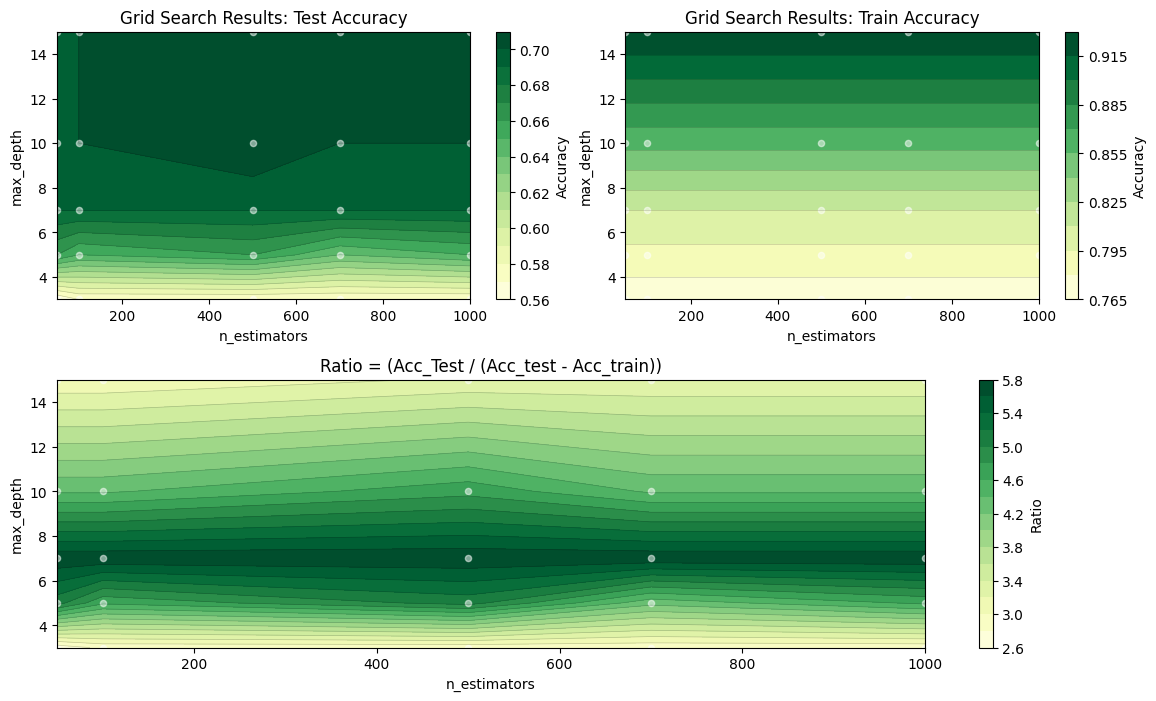

In [33]:
from scipy.interpolate import griddata
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

dfgs['mean_test'] = dfgs['mean_test_score'].apply(lambda x:np.round(x,2))
dfgs['mean_train'] = dfgs['mean_train_score'].apply(lambda x:np.round(x,2))

## X,Y,Z
n_estimators = dfgs['param_clf__n_estimators'].values
max_depth = dfgs['param_clf__max_depth'].values
accuracy = dfgs['mean_test'].values
accuracy_train = dfgs['mean_train'].values

# Create a regular grid
n_est_unique = np.sort(dfgs['param_clf__n_estimators'].unique())
max_depth_unique = np.sort(dfgs['param_clf__max_depth'].unique())
X, Y = np.meshgrid(n_est_unique, max_depth_unique)

# Interpolate the accuracy values onto the grid
Z = griddata((n_estimators, max_depth), accuracy, (X, Y), method='cubic')
Z_train = griddata((n_estimators,max_depth), accuracy_train, (X,Y), method='cubic')

## ------------------------------------
# Create figure with GridSpec
fig = plt.figure(figsize=(14, 8))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.3, wspace=0.1)

# Create axes: top row has 2 subplots, bottom row spans full width
ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1])
ax2 = fig.add_subplot(gs[1, :])  # Spans both columns

# Plot 1: Test Accuracy
CS = ax0.contourf(X, Y, Z, levels=15, cmap='YlGn')
ax0.contour(X, Y, Z, levels=15, colors='black', alpha=0.2, linewidths=0.5)
ax0.set_xlabel('n_estimators')
ax0.set_ylabel('max_depth')
ax0.set_title('Grid Search Results: Test Accuracy')
plt.colorbar(CS, ax=ax0, label='Accuracy')
ax0.scatter(n_estimators, max_depth, c='white', s=20, alpha=0.5, label='Grid points')

# Plot 2: Train Accuracy
CS = ax1.contourf(X, Y, Z_train, levels=15, cmap='YlGn')
ax1.contour(X, Y, Z_train, levels=15, colors='black', alpha=0.2, linewidths=0.5)
ax1.set_xlabel('n_estimators')
ax1.set_ylabel('max_depth')
ax1.set_title('Grid Search Results: Train Accuracy')
plt.colorbar(CS, ax=ax1, label='Accuracy')
ax1.scatter(n_estimators, max_depth, c='white', s=20, alpha=0.5, label='Grid points')

# Plot 3: Ratio (spans full width)
ratio = dfgs['ratio'].values
Z_ratio = griddata((n_estimators, max_depth), ratio, (X, Y), method='cubic')

CS = ax2.contourf(X, Y, Z_ratio, levels=15, cmap='YlGn')
ax2.contour(X, Y, Z_ratio, levels=15, colors='black', alpha=0.2, linewidths=0.5)
ax2.set_xlabel('n_estimators')
ax2.set_ylabel('max_depth')
ax2.set_title('Ratio = (Acc_Test / (Acc_test - Acc_train))')
plt.colorbar(CS, ax=ax2, label='Ratio')
ax2.scatter(n_estimators, max_depth, c='white', s=20, alpha=0.5, label='Grid points')

plt.show()

### SVC

In [14]:
svc_df=pd.read_csv('results/grid_search_SVC_full_df2.csv')
svc_df['mean_test'] = svc_df['mean_test_score'].apply(lambda x:np.round(x,2))
svc_df['mean_train'] = svc_df['mean_train_score'].apply(lambda x:np.round(x,2))
svc_df['diff_train_test'] = svc_df['mean_train'] - svc_df['mean_test']
svc_df['ratio'] = svc_df['mean_test']/svc_df['diff_train_test']
svc_df['ratio'] = svc_df['ratio'].apply(lambda x:np.round(x,2))
svc_df

,Unnamed: 0,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_clf__C,param_clf__gamma,param_clf__kernel,params,split0_test_score,...,split0_train_score,split1_train_score,split2_train_score,split3_train_score,mean_train_score,std_train_score,mean_test,mean_train,diff_train_test,ratio
0,0,3.819196,0.900755,1.837795,0.638415,0.01,0.0001,rbf,"{'clf__C': 0.01, 'clf__gamma': 0.0001, 'clf__k...",0.482178,...,0.567910,0.536711,0.525078,0.599365,0.557266,0.028915,0.46,0.56,0.10,4.60
1,1,3.835192,0.877880,1.908796,0.618934,0.01,0.0003,rbf,"{'clf__C': 0.01, 'clf__gamma': 0.0003, 'clf__k...",0.482178,...,0.567910,0.536711,0.525078,0.599365,0.557266,0.028915,0.46,0.56,0.10,4.60
2,2,3.802954,0.999365,1.993870,0.553670,0.01,0.0010,rbf,"{'clf__C': 0.01, 'clf__gamma': 0.001, 'clf__ke...",0.482178,...,0.567910,0.612580,0.705887,0.599365,0.621436,0.051387,0.37,0.62,0.25,1.48
3,3,3.424902,0.878311,1.971361,0.714152,0.01,0.0030,rbf,"{'clf__C': 0.01, 'clf__gamma': 0.003, 'clf__ke...",0.638119,...,0.761547,0.679638,0.745930,0.725065,0.728045,0.030799,0.53,0.73,0.20,2.65
4,4,2.884478,0.539772,1.734155,0.630412,0.01,0.0100,rbf,"{'clf__C': 0.01, 'clf__gamma': 0.01, 'clf__ker...",0.641337,...,0.770637,0.689550,0.758346,0.780631,0.749791,0.035665,0.57,0.75,0.18,3.17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,61,9.053551,3.522803,1.758195,0.661220,1000.00,0.1000,rbf,"{'clf__C': 1000, 'clf__gamma': 0.1, 'clf__kern...",0.598762,...,0.987422,0.997430,0.989887,0.988326,0.990766,0.003947,0.58,0.99,0.41,1.41
62,62,9.853380,4.689329,2.486609,0.875124,1000.00,0.3000,rbf,"{'clf__C': 1000, 'clf__gamma': 0.3, 'clf__kern...",0.640099,...,0.988479,0.997675,0.990873,0.989167,0.991549,0.003643,0.52,0.99,0.47,1.11
63,63,13.153861,5.850815,3.291686,1.085638,1000.00,1.0000,rbf,"{'clf__C': 1000, 'clf__gamma': 1, 'clf__kernel...",0.516584,...,0.991121,0.998409,0.992764,0.991128,0.993356,0.002993,0.38,0.99,0.61,0.62
64,64,16.377761,6.878143,3.317539,1.274851,1000.00,3.0000,rbf,"{'clf__C': 1000, 'clf__gamma': 3, 'clf__kernel...",0.517822,...,0.992707,0.998899,0.994573,0.993183,0.994840,0.002441,0.37,0.99,0.62,0.60


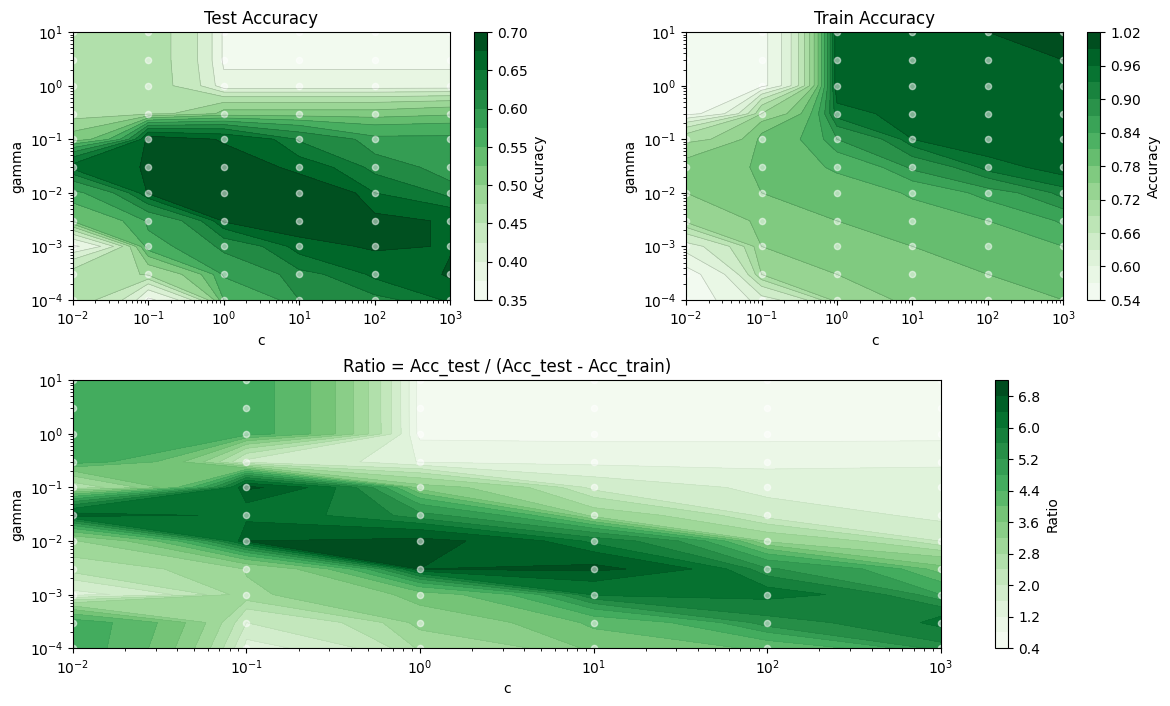

In [19]:
from scipy.interpolate import griddata
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

svc_df['mean_test'] = svc_df['mean_test_score'].apply(lambda x:np.round(x,2))
svc_df['mean_train'] = svc_df['mean_train_score'].apply(lambda x:np.round(x,2))

## X,Y,Z
c = svc_df['param_clf__C'].values
gamma = svc_df['param_clf__gamma'].values
accuracy = svc_df['mean_test'].values
accuracy_train = svc_df['mean_train'].values
ratio = svc_df['ratio'].values 

# Create a regular grid
c_unique = np.sort(svc_df['param_clf__C'].unique())
gamma_unique = np.sort(svc_df['param_clf__gamma'].unique())
X, Y = np.meshgrid(c_unique, gamma_unique)

# interpolate
Z = griddata((c, gamma), accuracy, (X, Y), method='cubic')
Z_train = griddata((c,gamma), accuracy_train, (X,Y), method='cubic')
Z_ratio = griddata((c,gamma), ratio, (X, Y), method='cubic')

## ------------------------------------
# gridSpec
fig = plt.figure(figsize=(14, 8))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.3, wspace=0.3)

# axes
ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1])
ax2 = fig.add_subplot(gs[1, :])  


# Plot 1: Test Accuracy
CS = ax0.contourf(X, Y, Z, levels=15, cmap='Greens')
ax0.contour(X, Y, Z, levels=15, colors='black', alpha=0.2, linewidths=0.5)
ax0.set_xlabel('c')
ax0.set_xscale("log")
ax0.set_ylabel('gamma')
ax0.set_yscale("log")   
ax0.set_title('Test Accuracy')
plt.colorbar(CS, ax=ax0, label='Accuracy')
ax0.scatter(c, gamma, c='white', s=20, alpha=0.5)


# Plot 2: Train Accuracy
CS = ax1.contourf(X, Y, Z_train, levels=15, cmap='Greens')
ax1.contour(X, Y, Z_train, levels=15, colors='black', alpha=0.2, linewidths=0.5)
ax1.set_xlabel('c')
ax1.set_xscale("log") 
ax1.set_ylabel('gamma')
ax1.set_yscale("log")    
ax1.set_title('Train Accuracy')
plt.colorbar(CS, ax=ax1, label='Accuracy')
ax1.scatter(c, gamma, c='white', s=20, alpha=0.5)


# Plot 3: Ratio
CS = ax2.contourf(X, Y, Z_ratio, levels=15, cmap='Greens')
ax2.contour(X, Y, Z_ratio, levels=15, colors='black', alpha=0.05, linewidths=0.5)
ax2.set_xlabel('c')
ax2.set_xscale("log") 
ax2.set_ylabel('gamma')
ax2.set_yscale("log")     
ax2.set_title('Ratio = Acc_test / (Acc_test - Acc_train)')
plt.colorbar(CS, ax=ax2, label='Ratio')
ax2.scatter(c, gamma, c='white', s=20, alpha=0.5)

## Testing the models

Here we gonna train the choose ML model in the full dataset with the hyperparameters tunned and apply to the yTEST

Lets repeat this with the full Xtrain features and with the Xtrain features selected.

In [20]:
from sklearn.compose import make_column_selector
from src.inference import train_test_predict
from src.utils import results_to_dataframe

<Axes: >

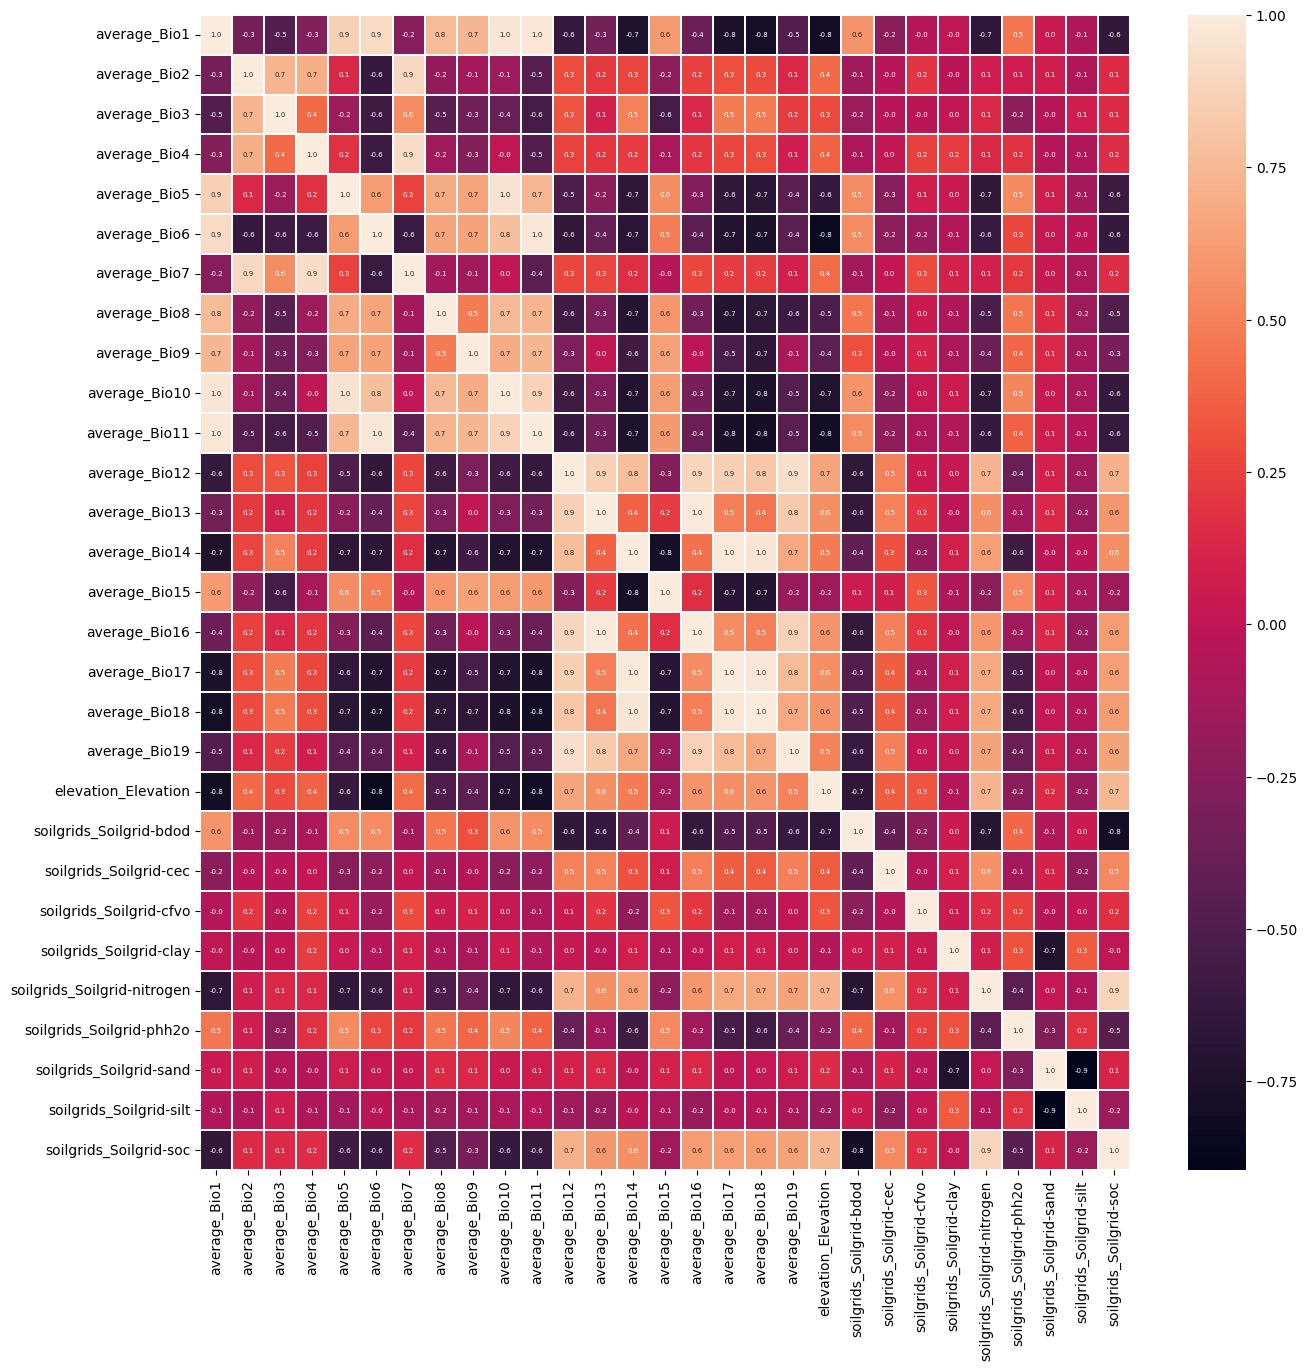

In [ ]:
df_corr = X_without_lc.corr()
fig, ax = plt.subplots(figsize=(10,10))
sns.heatmap(df_corr, annot=True, fmt=".1f", ax=ax, linewidths=0.2, annot_kws={"fontsize":5})


In [168]:
#  define Feature Sets ---

# features to drop for No Human Footprint
hf_cols = [
    'footprint_HumanFootprint-Railways', 'footprint_HumanFootprint-Roads',
    'Built-1994-2009', 'croplands-1992-2005', 'Lights-1994-2009',
    'NavWater-1994-2009', 'Pasture-1993-2009', 'Popdensity-1990-2010',
    'HFP-1993-2009'
]

# Columns from permutation selection | selection from permutation selection
perm_select = [
    'average_Bio15','elevation_Elevation','soilgrids_Soilgrid-phh2o','landcover_LandCover',
    'soilgrids_Soilgrid-cfvo', 'average_Bio12', 'soilgrids_Soilgrid-cec',
    'soilgrids_Soilgrid-clay', 'average_Bio2', 'average_Bio7','Popdensity-1990-2010',
    'average_Bio19', 'average_Bio3','Pasture-1993-2009', 'average_Bio9', 
    'soilgrids_Soilgrid-sand','average_Bio14','Lights-1994-2009','average_Bio13', 
    'average_Bio17', 'Built-1994-2009'
]

# Non-climatic features 
non_climatic_cols = [
    'landcover_LandCover', 'soilgrids_Soilgrid-bdod', 'soilgrids_Soilgrid-cec', 
    'soilgrids_Soilgrid-cfvo', 'soilgrids_Soilgrid-clay', 'soilgrids_Soilgrid-nitrogen',
    'soilgrids_Soilgrid-phh2o', 'soilgrids_Soilgrid-sand', 'soilgrids_Soilgrid-silt', 
    'soilgrids_Soilgrid-soc', 'footprint_HumanFootprint-Railways', 'footprint_HumanFootprint-Roads',
    'Built-1994-2009', 'croplands-1992-2005', 'Lights-1994-2009', 'NavWater-1994-2009', 
    'Pasture-1993-2009', 'Popdensity-1990-2010', 'HFP-1993-2009'
]

#  Create the Data Subsets ---
# No Human Footprint ('no_hfootp')
X_no_hf = X.drop(columns=hf_cols, axis=1).copy()
X_no_hf_test = X_full_test.drop(columns=hf_cols,axis=1).copy()

# No HF & No Land Cover ('no_hf_lc')
drop_lc = ['landcover_LandCover']
X_no_hf_lc = X_no_hf.drop(columns=drop_lc, axis=1).copy()
X_no_hf_lc_test = X_no_hf_test.drop(columns=drop_lc, axis=1).copy()
X_no_hf_lc_test = X_no_hf_lc_test[X_no_hf_lc.columns] # Ensure column order matches

# Feature Importance Selection ('feats_import')
X_imp = X[perm_select].copy()
X_imp_test = X_full_test[perm_select].copy()

# Climatic Only ('climatic')
X_cli = X.drop(columns = non_climatic_cols, axis=1).copy()
X_cli_test = X_full_test.drop(columns=non_climatic_cols, axis=1).copy()

# --- 3. Prepare the Loop Data Structure ---

loop_datasets = [
    ('full_df', X, X_full_test),
    ('no_hfootp', X_no_hf, X_no_hf_test),
    ('no_hf_lc', X_no_hf_lc, X_no_hf_lc_test),
    ('feats_import', X_imp, X_imp_test),
    ('climatic', X_cli, X_cli_test)
]

### RandomForest

In [171]:
## --- Global results dictionary ---
global_scores = dict()

## --- Define the Preprocessor (Constant) ---
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), make_column_selector(dtype_include=np.number)),
        ('cat', OneHotEncoder(handle_unknown='ignore'), make_column_selector(dtype_include=object))
    ],
    remainder='passthrough'
)

## --- Define the Model (Constant) ---
# Removed max_depth=5 to allow for feature sensitivity
model_rf = [
    ("clf", RandomForestClassifier(n_estimators=200,
                                   random_state=420,
                                   max_depth=8,
                                   n_jobs=-1))
]


## --- Run the Loop ---
for name, X_train, X_x_test in loop_datasets: 
    print("- -"*20)
    print(f"Running: **{name}**")
    print(f"Train/Test Shapes: {X_train.shape} / {X_x_test.shape}")
    
    # Run the prediction using your existing function
    scores = train_test_predict(X_train, X_x_test, y, y_full_test, model_rf, preprocessor)

    ## Add results to dict
    global_scores[name] = scores

print("- -"*20)
print("Finished standard feature selection runs.")


## --- PCA Transformation ---
# only fit PCA on the training data (X)
pca = PCA(n_components=8, random_state=420)
pca.fit(X) 
X_pca = pd.DataFrame(pca.transform(X)) 
Xtest_pca = pd.DataFrame(pca.transform(X_full_test)) 

## --- Run PCA Prediction ---
print('\nRunning **PCA**')

# The model and preprocessor definitions are the same as above.

# Compute scores
scores_pca = train_test_predict(X_pca, Xtest_pca, y, y_full_test, model_rf, preprocessor)
global_scores['pca'] = scores_pca

- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -
Running: **full_df**
Train/Test Shapes: (13501, 39) / (1386, 39)
Train class distribution: [7321 6180]
Test class distribution: [978 408]
Training the Model


Training time: 8.30s
Predicting train
Predicting test
Total time taken: 9.74s
- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -
Running: **no_hfootp**
Train/Test Shapes: (13501, 30) / (1386, 30)
Train class distribution: [7321 6180]
Test class distribution: [978 408]
Training the Model
Training time: 4.96s
Predicting train
Predicting test
Total time taken: 5.71s
- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -
Running: **no_hf_lc**
Train/Test Shapes: (13501, 29) / (1386, 29)
Train class distribution: [7321 6180]
Test class distribution: [978 408]
Training the Model
Training time: 4.99s
Predicting train
Predicting test
Total time taken: 5.64s
- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -
Running: **feats_import**
Train/Test Shapes: (13501, 21) / (1386, 21)
Train class distribution: [7321 6180]
Test class distribution: [978 408]
Training the Model
Training time: 3.95s
Predicting train
Predicting test
Total time taken: 6.46s
- -- -- -- -- -- -- -- -- 

#### Plot RF

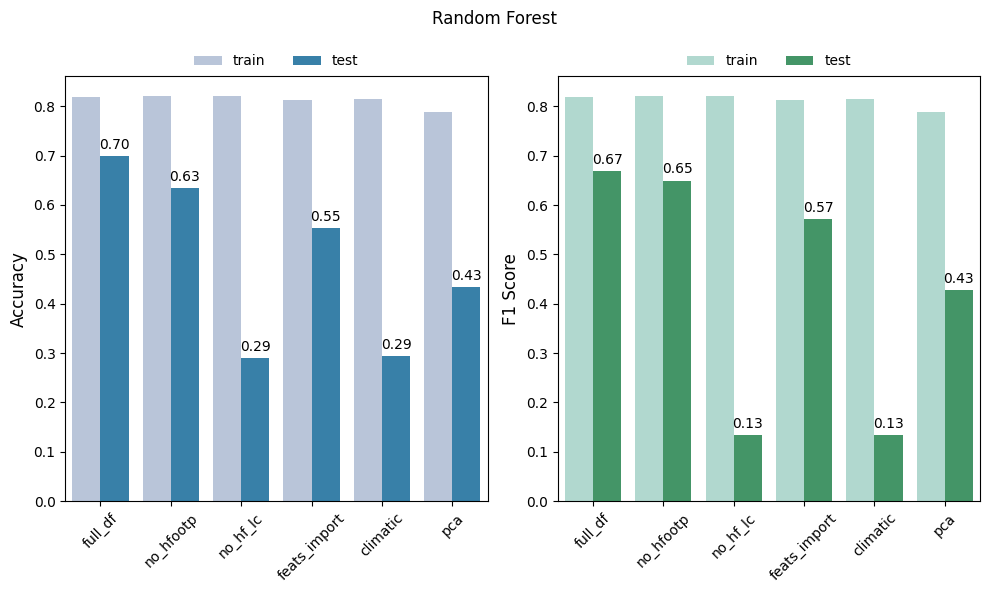

In [172]:
df_results = results_to_dataframe(global_scores)

fig, ax= plt.subplots(nrows=1, ncols=2, figsize=(10,6))

sns.barplot(df_results,
            x='dataset',
            y='accuracy',
            hue='split',
            palette='PuBu',
            ax=ax[0])

ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=45)

sns.barplot(df_results,
             x='dataset',
             y = 'f1',
             hue='split',
             palette='BuGn',
             ax=ax[1])

ax[0].set_ylabel('Accuracy', {'fontsize':12})
ax[1].set_ylabel('F1 Score', {'fontsize':12})
ax[0].set_xlabel('')
ax[1].set_xlabel('')

ax[1].set_xticklabels(ax[1].get_xticklabels(),rotation=45)

## # labels 
for i, container in enumerate(ax[0].containers):

    if i == 1:  
        ax[0].bar_label(container, fmt='%.2f', padding=3)

for i, container in enumerate(ax[1].containers):
    if i == 1:  
        ax[1].bar_label(container, fmt='%.2f', padding=3)
        
## legend
ax[0].legend(loc='upper center', bbox_to_anchor=(0.5, 1.08), ncol=2, frameon=False)
ax[1].legend(loc='upper center', bbox_to_anchor=(0.5, 1.08), ncol=2, frameon=False)

plt.suptitle('Random Forest')
plt.tight_layout()
plt.show()

### SVM

In [ ]:
## --- Global results dictionary ---
global_scores = dict()

## --- Define the Preprocessor (Constant) ---
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), make_column_selector(dtype_include=np.number)),
        ('cat', OneHotEncoder(handle_unknown='ignore'), make_column_selector(dtype_include=object))
    ],
    remainder='passthrough'
)

## --- Define the Model 
model_rf = [
    ("clf", SVC(probability=true, C=1, gamma=10^-2, random_state=420, kernel='rbf'))
]


## --- Run the Loop ---
for name, X_train, X_x_test in loop_datasets: 
    print("- -"*20)
    print(f"Running: **{name}**")
    print(f"Train/Test Shapes: {X_train.shape} / {X_x_test.shape}")
    
    # Run the prediction using your existing function
    scores = train_test_predict(X_train, X_x_test, y, y_full_test, model_rf, preprocessor)

    ## Add results to dict
    global_scores[name] = scores

print("- -"*20)
print("Finished standard feature selection runs.")


## --- PCA Transformation ---
# only fit PCA on the training data (X)
pca = PCA(n_components=8, random_state=420)
pca.fit(X) 
X_pca = pd.DataFrame(pca.transform(X)) 
Xtest_pca = pd.DataFrame(pca.transform(X_full_test)) 

## --- Run PCA Prediction ---
print('\nRunning **PCA**')

# The model and preprocessor definitions are the same as above.

# Compute scores
scores_pca = train_test_predict(X_pca, Xtest_pca, y, y_full_test, model_rf, preprocessor)
global_scores['pca'] = scores_pca

- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -
Running: full_df
Dataset shape:(13501, 39)
 Test Dataset: (1386, 39)
Training the Model


Training time: 119.304s
Predicting train
Calculating metrics...
Predicting test
Calculating metrics...
Time taken: 151.08
- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -
Running: no_hfootp
Dataset shape:(13501, 30)
 Test Dataset: (1386, 30)
Training the Model
Training time: 110.810s
Predicting train
Calculating metrics...
Predicting test
Calculating metrics...
Time taken: 136.73
- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -
Running: no_hf_lc
Dataset shape:(13501, 29)
 Test Dataset: (1386, 29)
Training the Model
Training time: 87.092s
Predicting train
Calculating metrics...
Predicting test
Calculating metrics...
Time taken: 113.02
- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -
Running: feats_import
Dataset shape:(13501, 18)
 Test Dataset: (1386, 18)
Training the Model
Training time: 75.349s
Predicting train
Calculating metrics...
Predicting test
Calculating metrics...
Time taken: 97.58
- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -

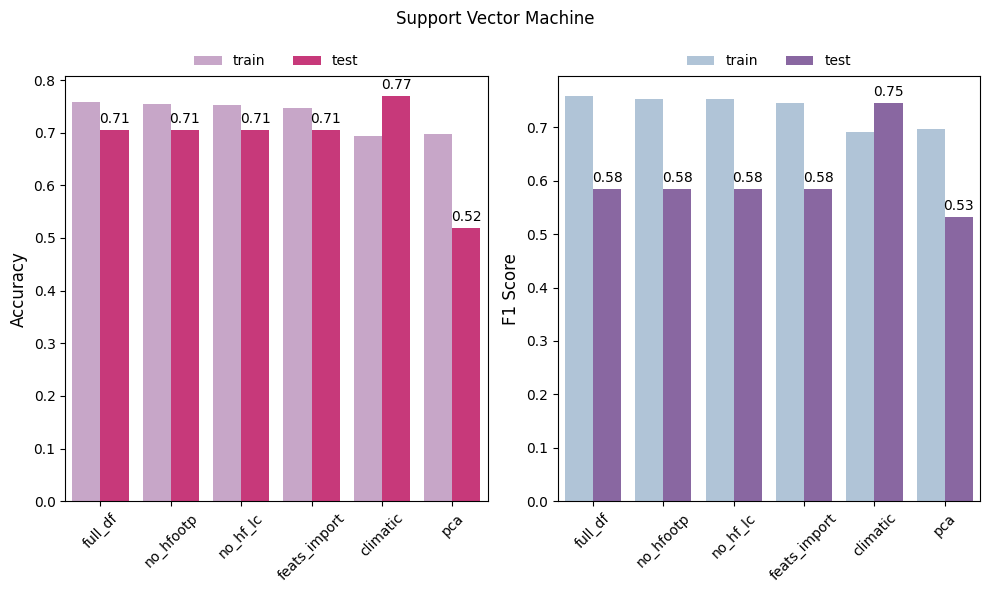

In [105]:
svm_results = results_to_dataframe(global_scores)

fig, ax= plt.subplots(nrows=1, ncols=2, figsize=(10,6))

sns.barplot(df_results,
            x='dataset',
            y='accuracy',
            hue='split',
            palette='PuRd',
            ax=ax[0])

ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=45)

sns.barplot(df_results,
             x='dataset',
             y = 'f1',
             hue='split',
             palette='BuPu',
             ax=ax[1])

ax[0].set_ylabel('Accuracy', {'fontsize':12})
ax[1].set_ylabel('F1 Score', {'fontsize':12})
ax[0].set_xlabel('')
ax[1].set_xlabel('')

ax[1].set_xticklabels(ax[1].get_xticklabels(),rotation=45)

## # labels 
for i, container in enumerate(ax[0].containers):

    if i == 1:  
        ax[0].bar_label(container, fmt='%.2f', padding=3)

for i, container in enumerate(ax[1].containers):
    if i == 1:  
        ax[1].bar_label(container, fmt='%.2f', padding=3)
        
## legend
ax[0].legend(loc='upper center', bbox_to_anchor=(0.5, 1.08), ncol=2, frameon=False)
ax[1].legend(loc='upper center', bbox_to_anchor=(0.5, 1.08), ncol=2, frameon=False)

plt.suptitle('Support Vector Machine')
plt.tight_layout()
plt.show()

## Error Evaluation

-Here we are tring to evaluate the error of the model.
- Lets focus on see if we find bias on the prediction and how the spatial distribution the error is given
- For the same area, try to apply some UMAP to see if the feature space is very similar and therefore the model is predicting a true label as false

# FIND BUG

## 

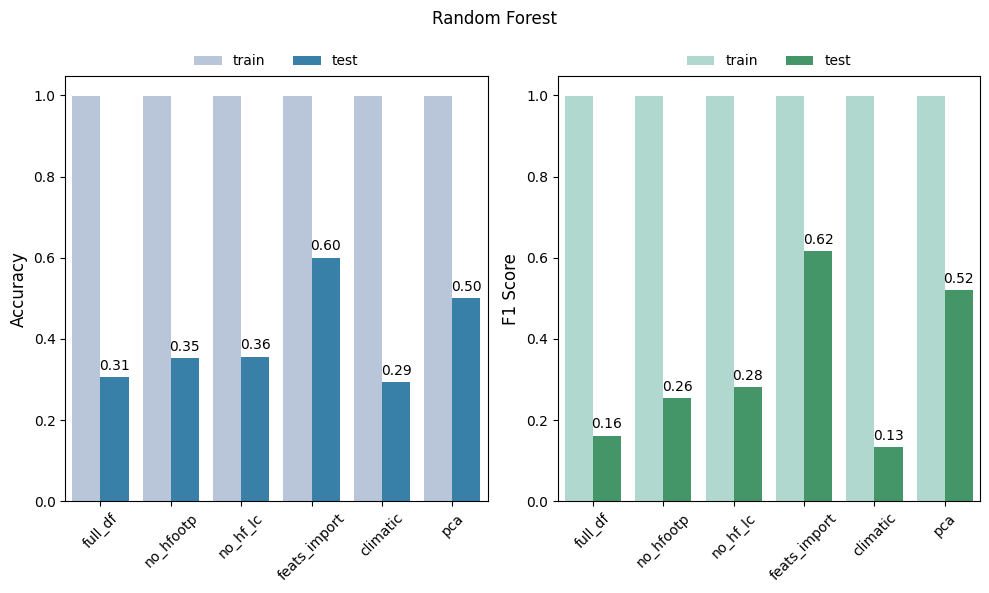

In [166]:
df_results = results_to_dataframe(global_scores)

fig, ax= plt.subplots(nrows=1, ncols=2, figsize=(10,6))

sns.barplot(df_results,
            x='dataset',
            y='accuracy',
            hue='split',
            palette='PuBu',
            ax=ax[0])

ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=45)

sns.barplot(df_results,
             x='dataset',
             y = 'f1',
             hue='split',
             palette='BuGn',
             ax=ax[1])

ax[0].set_ylabel('Accuracy', {'fontsize':12})
ax[1].set_ylabel('F1 Score', {'fontsize':12})
ax[0].set_xlabel('')
ax[1].set_xlabel('')

ax[1].set_xticklabels(ax[1].get_xticklabels(),rotation=45)

## # labels 
for i, container in enumerate(ax[0].containers):

    if i == 1:  
        ax[0].bar_label(container, fmt='%.2f', padding=3)

for i, container in enumerate(ax[1].containers):
    if i == 1:  
        ax[1].bar_label(container, fmt='%.2f', padding=3)
        
## legend
ax[0].legend(loc='upper center', bbox_to_anchor=(0.5, 1.08), ncol=2, frameon=False)
ax[1].legend(loc='upper center', bbox_to_anchor=(0.5, 1.08), ncol=2, frameon=False)

plt.suptitle('Random Forest')
plt.tight_layout()
plt.show()